In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import itertools
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [2]:
df = pd.read_csv("../data/processed/tickets_clean.csv")

tag_cols = [c for c in df.columns if c.startswith("tag_")]
print(tag_cols)
print(df.shape)

['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
(28580, 16)


In [6]:
def collect_tags(row):
    tags = []
    for col in tag_cols:
        val = str(row[col]).strip()
        if val and val.lower() not in ["nan", ""]:
            tags.append(val)
    return tags

df["tags_list"] = df.apply(collect_tags, axis=1)
df["tag_count"] = df["tags_list"].apply(len)

print(df["tag_count"].value_counts().sort_index())

tag_count
1       13
2      123
3     2920
4    10983
5     8669
6     3833
7     1475
8      564
Name: count, dtype: int64


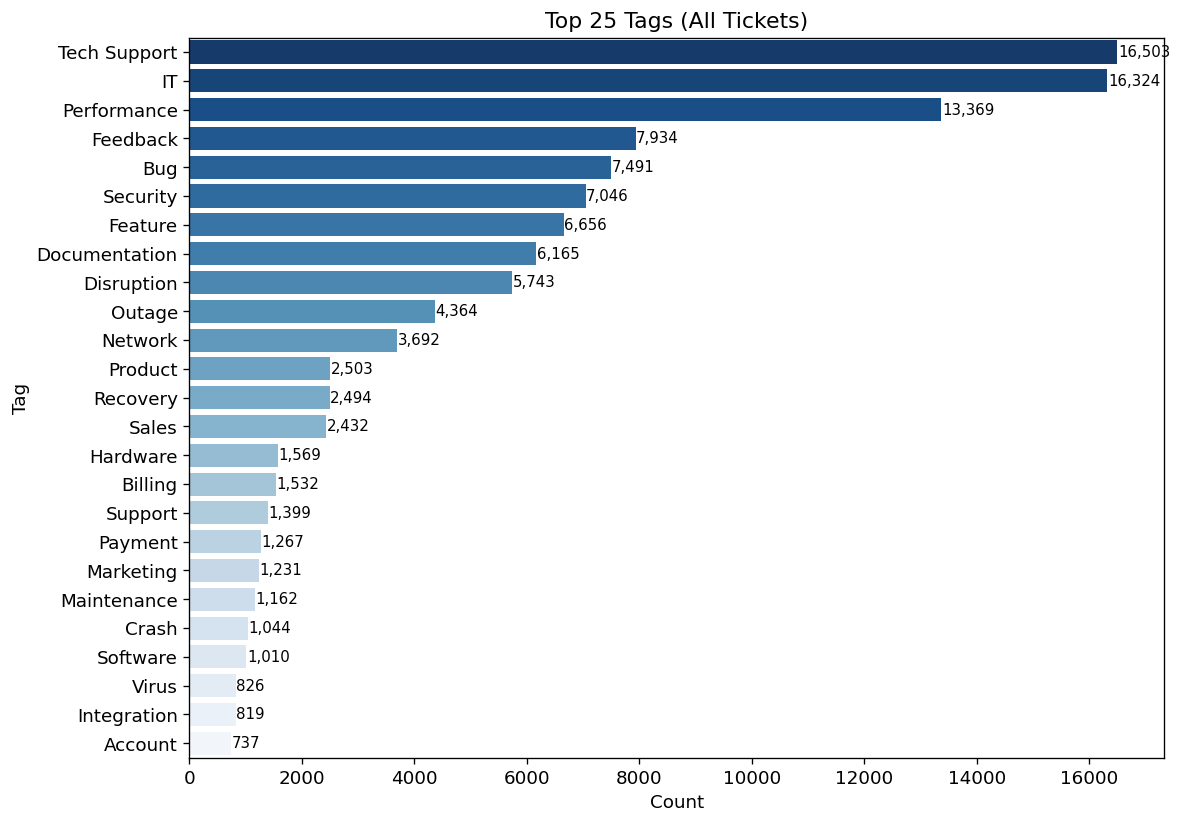

In [7]:
# 전체 태그 빈도 Top 25
all_tags = list(itertools.chain.from_iterable(df["tags_list"]))
tag_counter = Counter(all_tags)
top25 = pd.DataFrame(tag_counter.most_common(25), columns=["tag", "count"])

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top25, x="count", y="tag", palette="Blues_r", ax=ax)
ax.set_title("Top 25 Tags (All Tickets)")
ax.set_xlabel("Count")
ax.set_ylabel("Tag")
for i, v in enumerate(top25["count"]):
    ax.text(v + 10, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/03_tag_top25.png")
plt.show()

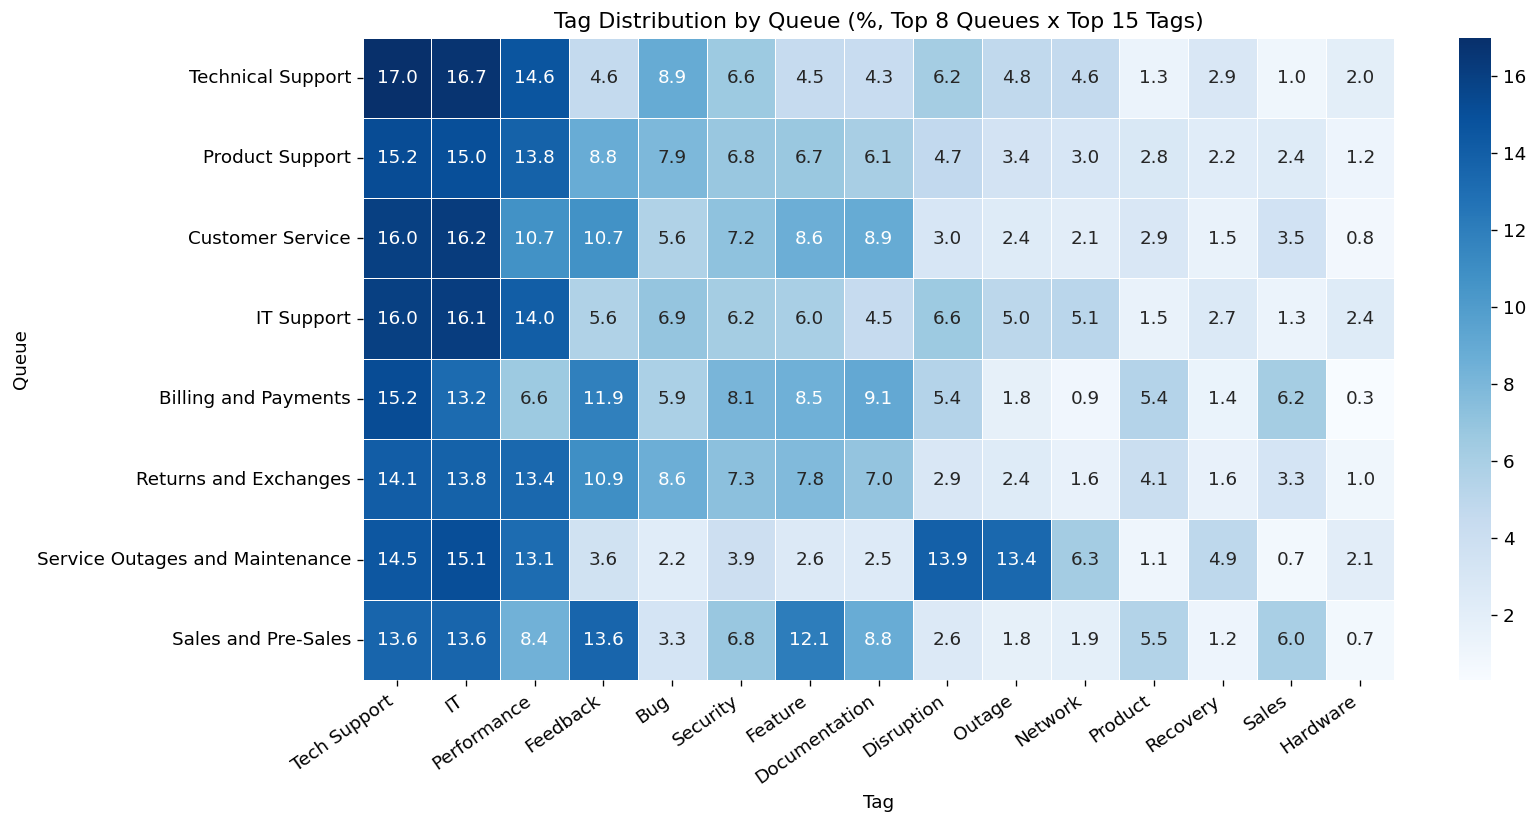

In [ ]:
# 큐별 Top 5 태그 히트맵

top_queues = df["queue"].value_counts().head(8).index
top_tags   = [t for t, _ in tag_counter.most_common(15)]

queue_tag_matrix = pd.DataFrame(index=top_queues, columns=top_tags, data=0)

for queue in top_queues:
    sub = df[df["queue"] == queue]["tags_list"]
    sub_tags = list(itertools.chain.from_iterable(sub))
    sub_counter = Counter(sub_tags)
    for tag in top_tags:
        queue_tag_matrix.loc[queue, tag] = sub_counter.get(tag, 0)

queue_tag_matrix = queue_tag_matrix.astype(int)

queue_tag_norm = queue_tag_matrix.div(queue_tag_matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    queue_tag_norm.round(1),
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Tag Distribution by Queue (%, Top 8 Queues x Top 15 Tags)")
ax.set_xlabel("Tag")
ax.set_ylabel("Queue")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/03_queue_tag_heatmap.png")
plt.show()

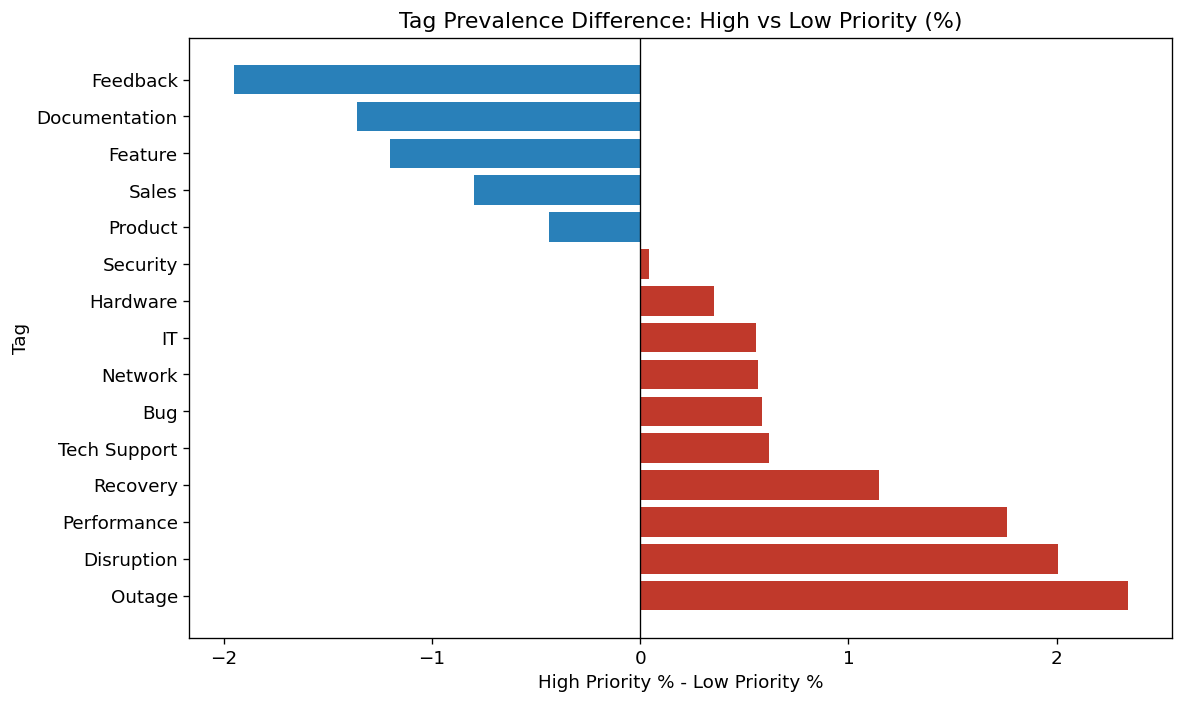

In [11]:
# high priority 티켓 vs 전체 - 태그 비율 비교
all_tags_high   = list(itertools.chain.from_iterable(df[df["priority"] == "high"]["tags_list"]))
all_tags_low    = list(itertools.chain.from_iterable(df[df["priority"] == "low"]["tags_list"]))

counter_high    = Counter(all_tags_high)
counter_low     = Counter(all_tags_low)
n_high          = len(all_tags_high)
n_low           = len(all_tags_low)

compare = pd.DataFrame({
    "tag"       : top_tags,
    "high_pct"  : [counter_high.get(t, 0) / n_high * 100 for t in top_tags],
    "low_pct"   : [counter_low.get(t, 0)  / n_low  * 100 for t in top_tags],
})
compare["diff"] = compare["high_pct"] - compare["low_pct"]
compare = compare.sort_values("diff", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if v >= 0 else "#2980b9" for v in compare["diff"]]
ax.barh(compare["tag"], compare["diff"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Tag Prevalence Difference: High vs Low Priority (%)")
ax.set_xlabel("High Priority % - Low Priority %")
ax.set_ylabel("Tag")
plt.tight_layout()
plt.savefig("../outputs/figures/03_tag_priority_diff.png")
plt.show()

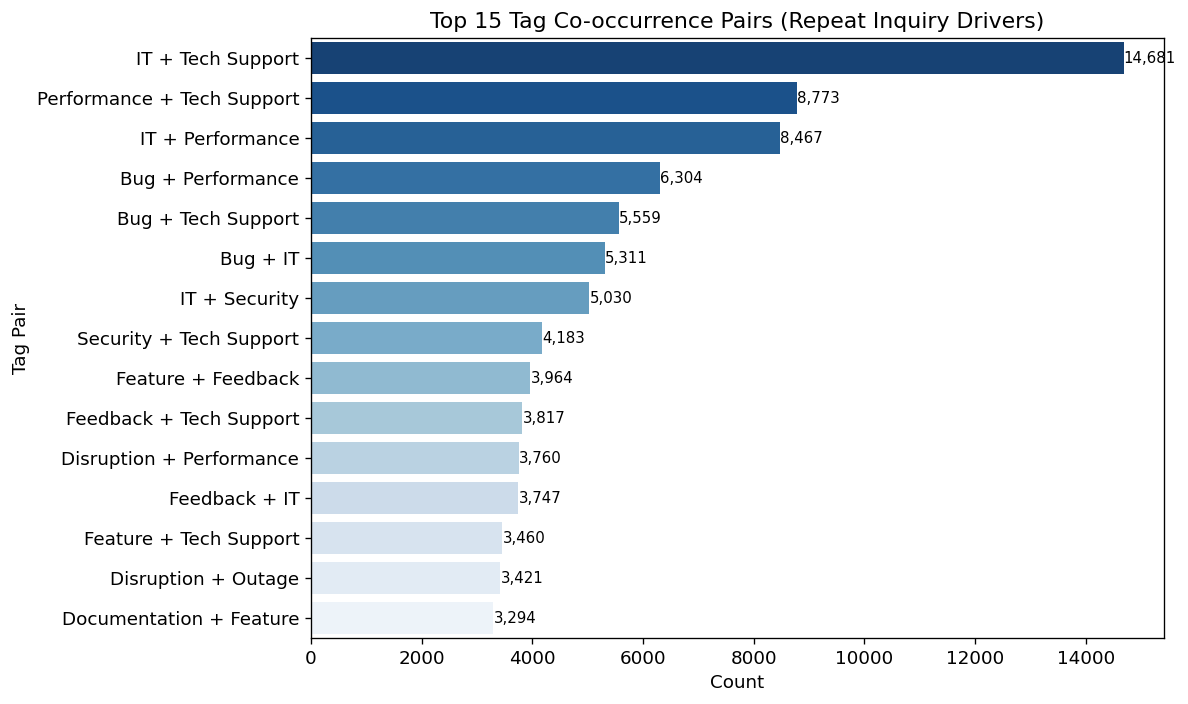

In [13]:
# 반복 문의 드라이버 - 태그 조합 Top 15

pair_counter = Counter()

for tags in df["tags_list"]:
    unique_tags = list(set(tags))
    for pair in itertools.combinations(sorted(unique_tags), 2):
        pair_counter[pair] += 1

top_pairs = pd.DataFrame(pair_counter.most_common(15), columns=["pair", "count"])
top_pairs["pair_str"] = top_pairs["pair"].apply(lambda x: f"{x[0]} + {x[1]}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_pairs, x="count", y="pair_str", palette="Blues_r", ax=ax)
ax.set_title("Top 15 Tag Co-occurrence Pairs (Repeat Inquiry Drivers)")
ax.set_xlabel("Count")
ax.set_ylabel("Tag Pair")
for i, v in enumerate(top_pairs["count"]):
    ax.text(v + 5, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/03_tag_cooccurrence.png")
plt.show()